In [1]:
import pandas as pd

# URL del archivo JSON en formato Raw
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Cargar los datos directamente a un DataFrame
df = pd.read_json(url)

# Mostrar las primeras 5 filas
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   str   
 1   Churn       7267 non-null   str   
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(4), str(2)
memory usage: 340.8+ KB


In [3]:
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

df_transformado = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

print("Nuevas dimensiones:", df_transformado.shape)
df_transformado.head()

Nuevas dimensiones: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
print("--- VALORES NULOS POR COLUMNA ---")
print(df_transformado.isnull().sum())
print("\n") # Salto de línea

print("--- FILAS DUPLICADAS ---")
print("Total de duplicados:", df_transformado.duplicated().sum())
print("\n")

print("--- VALORES ÚNICOS EN 'Churn' ---")
print(df_transformado['Churn'].unique())
print("\n")

print("--- VALORES ÚNICOS EN 'gender' ---")
print(df_transformado['gender'].unique())

--- VALORES NULOS POR COLUMNA ---
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


--- FILAS DUPLICADAS ---
Total de duplicados: 0


--- VALORES ÚNICOS EN 'Churn' ---
<StringArray>
['No', 'Yes', '']
Length: 3, dtype: str


--- VALORES ÚNICOS EN 'gender' ---
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [5]:
df_limpio = df_transformado[df_transformado['Churn'] != '']
df_limpio = df_limpio[df_limpio['Churn'] != ' ']

df_limpio['Charges.Total'] = pd.to_numeric(df_limpio['Charges.Total'], errors='coerce')

nulos_descubiertos = df_limpio['Charges.Total'].isnull().sum()
print(f"Nulos reales descubiertos en Charges.Total: {nulos_descubiertos}")

df_limpio = df_limpio.dropna()

df_limpio = df_limpio.reset_index(drop=True)

print("¡Limpieza completada! Tamaño final del dataset:", df_limpio.shape)

Nulos reales descubiertos en Charges.Total: 11
¡Limpieza completada! Tamaño final del dataset: (7032, 21)


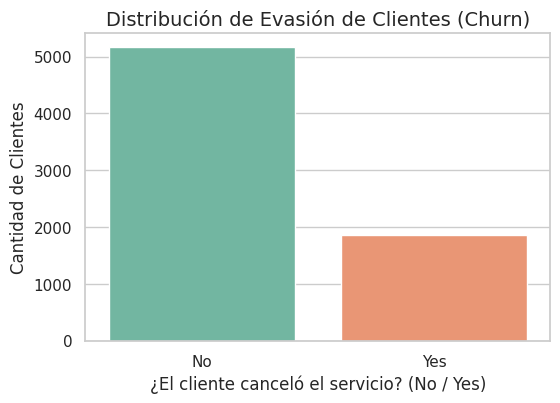

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_limpio, x='Churn', hue='Churn', palette='Set2')

plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=14)
plt.xlabel('¿El cliente canceló el servicio? (No / Yes)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

plt.show()

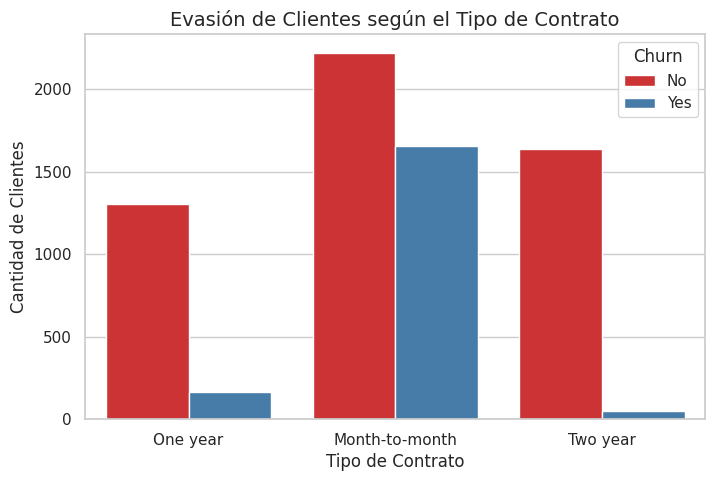

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_limpio, x='Contract', hue='Churn', palette='Set1')

plt.title('Evasión de Clientes según el Tipo de Contrato', fontsize=14)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

plt.show()

In [8]:
df_avanzado = df_limpio.copy()

df_avanzado['Churn'] = df_avanzado['Churn'].map({'Yes': 1, 'No': 0})

columnas_binarias = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in columnas_binarias:
    df_avanzado[col] = df_avanzado[col].map({'Yes': 1, 'No': 0})

df_avanzado['gender'] = df_avanzado['gender'].map({'Male': 1, 'Female': 0})

df_avanzado['tenure'] = pd.to_numeric(df_avanzado['tenure'])
df_avanzado['Charges.Monthly'] = pd.to_numeric(df_avanzado['Charges.Monthly'])

print("¡Transformación exitosa! Mira cómo ahora tenemos 1s y 0s:")
df_avanzado[['gender', 'Partner', 'tenure', 'PaperlessBilling', 'Churn']].head()

¡Transformación exitosa! Mira cómo ahora tenemos 1s y 0s:


,gender,Partner,tenure,PaperlessBilling,Churn
0,0,1,9,1,0
1,1,0,9,0,0
2,1,0,4,1,1
3,1,1,13,1,1
4,0,1,3,1,1


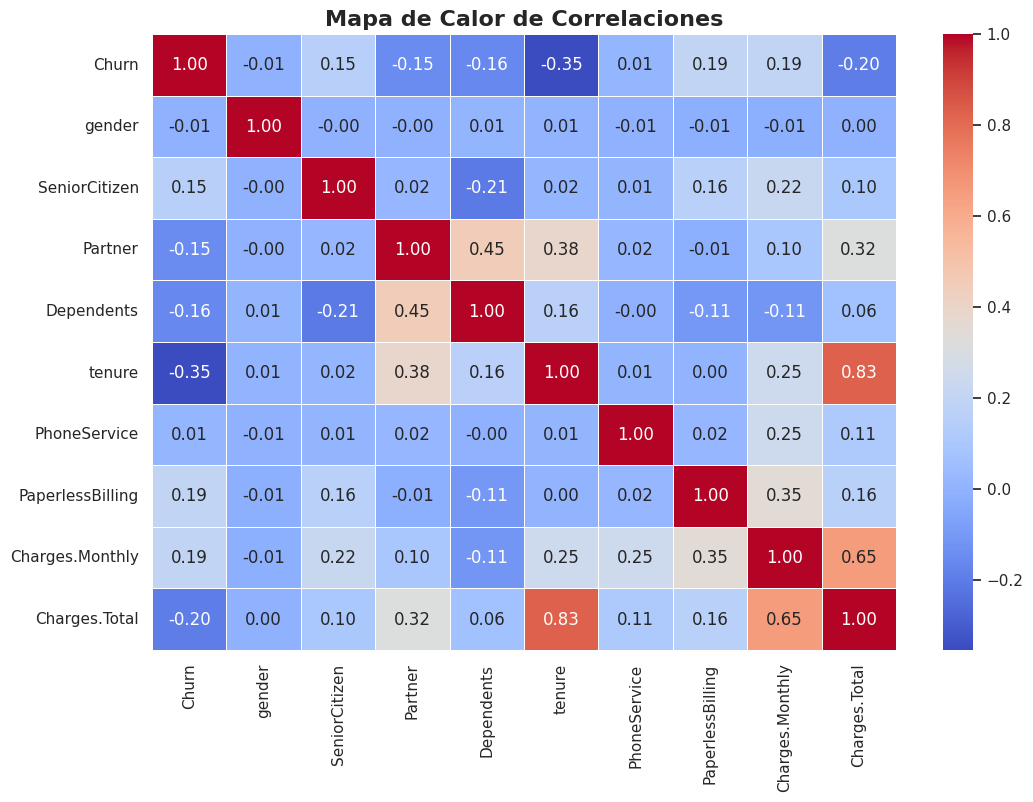

In [9]:
df_numerico = df_avanzado.select_dtypes(include=['number'])

correlacion = df_numerico.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Mapa de Calor de Correlaciones', fontsize=16, fontweight='bold')

plt.show()

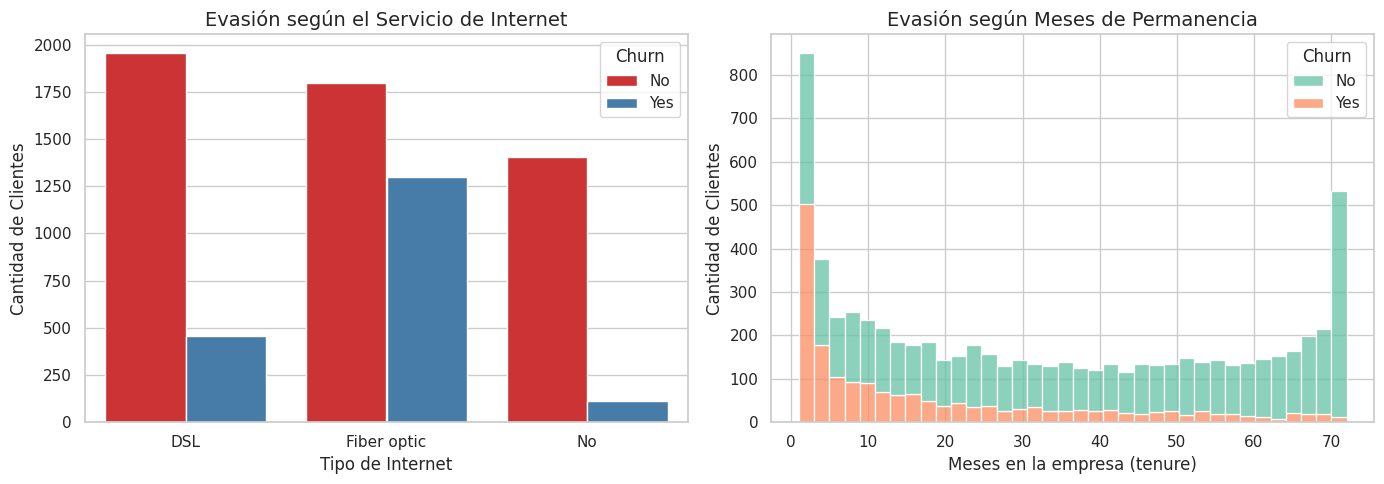

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_limpio, x='InternetService', hue='Churn', palette='Set1', ax=axes[0])
axes[0].set_title('Evasión según el Servicio de Internet', fontsize=14)
axes[0].set_xlabel('Tipo de Internet', fontsize=12)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=12)

sns.histplot(data=df_limpio, x='tenure', hue='Churn', multiple='stack', palette='Set2', ax=axes[1], bins=36)
axes[1].set_title('Evasión según Meses de Permanencia', fontsize=14)
axes[1].set_xlabel('Meses en la empresa (tenure)', fontsize=12)
axes[1].set_ylabel('Cantidad de Clientes', fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
fibra_sin_soporte = df_limpio[(df_limpio['InternetService'] == 'Fiber optic') & (df_limpio['TechSupport'] == 'No')]
tasa_fuga_sin = (fibra_sin_soporte['Churn'] == 'Yes').mean() * 100

fibra_con_soporte = df_limpio[(df_limpio['InternetService'] == 'Fiber optic') & (df_limpio['TechSupport'] == 'Yes')]
tasa_fuga_con = (fibra_con_soporte['Churn'] == 'Yes').mean() * 100

print("🔍 SECRETO 1: LA VERDAD SOBRE LA FIBRA ÓPTICA")
print(f"Tasa de abandono de Fibra Óptica SIN Soporte Técnico: {tasa_fuga_sin:.1f}%")
print(f"Tasa de abandono de Fibra Óptica CON Soporte Técnico: {tasa_fuga_con:.1f}%\n")


print("🔍 SECRETO 2: EL ASESINO SILENCIOSO (MÉTODOS DE PAGO)")
metodos_pago = df_limpio.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print(metodos_pago)

🔍 SECRETO 1: LA VERDAD SOBRE LA FIBRA ÓPTICA
Tasa de abandono de Fibra Óptica SIN Soporte Técnico: 49.4%
Tasa de abandono de Fibra Óptica CON Soporte Técnico: 22.6%

🔍 SECRETO 2: EL ASESINO SILENCIOSO (MÉTODOS DE PAGO)
PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64


In [12]:
dinero_perdido_mensual = df_limpio[df_limpio['Churn'] == 'Yes']['Charges.Monthly'].sum()
dinero_retenido = df_limpio[df_limpio['Churn'] == 'No']['Charges.Monthly'].sum()
ingreso_total_potencial = dinero_perdido_mensual + dinero_retenido

print("💸 SECRETO 3: EL IMPACTO FINANCIERO")
print(f"Ingresos mensuales perdidos por Churn: ${dinero_perdido_mensual:,.2f}")
print(f"Ingresos mensuales retenidos: ${dinero_retenido:,.2f}")
print(f"El Churn se está comiendo el {(dinero_perdido_mensual/ingreso_total_potencial)*100:.1f}% de los ingresos mensuales.\n")


solitarios = df_limpio[(df_limpio['Partner'] == 'No') & (df_limpio['Dependents'] == 'No')]
familias = df_limpio[(df_limpio['Partner'] == 'Yes') & (df_limpio['Dependents'] == 'Yes')]

tasa_fuga_solitarios = (solitarios['Churn'] == 'Yes').mean() * 100
tasa_fuga_familias = (familias['Churn'] == 'Yes').mean() * 100

print("👨‍👩‍👧‍👦 SECRETO 4: EL EFECTO DEL 'ANCLA FAMILIAR'")
print(f"Evasión en clientes Solitarios (sin pareja ni dependientes): {tasa_fuga_solitarios:.1f}%")
print(f"Evasión en clientes Familiares (con pareja y dependientes): {tasa_fuga_familias:.1f}%")

💸 SECRETO 3: EL IMPACTO FINANCIERO
Ingresos mensuales perdidos por Churn: $139,130.85
Ingresos mensuales retenidos: $316,530.15
El Churn se está comiendo el 30.5% de los ingresos mensuales.

👨‍👩‍👧‍👦 SECRETO 4: EL EFECTO DEL 'ANCLA FAMILIAR'
Evasión en clientes Solitarios (sin pareja ni dependientes): 34.2%
Evasión en clientes Familiares (con pareja y dependientes): 14.3%
